Exploratory Data Analysis

1. Data Ingestion & Chunk-Loading Strategy

The Alibaba TaoBao UserBehaviour dataset is anonymous user transacating behaviour in a short-term promotion of digital platform. This dataset contains approximately 100 million micro-behaviour logs, with a raw file size of 3.67GB. In order to aviod the risk of Out-of Memory (OOM), we will use a chunk reading algorithm. Besides, during data preprocessing stage, we design 3 dimensions for  data cleaning and feature extraction. First,Timestamp Noise Filtering. Second,Macro Behavior Aggregation. Third, Data Leakage Prevention & Micro-feature Extraction.

In [1]:
# 1.1 data chunk-loading strategy
# import modules
import pandas as pd
import numpy as np
import time

# basic paramters setting
data_path = r'../data/UserBehavior.csv'
columns = ['user_id', 'item_id', 'category_id', 'behaviour_type', 'timestamp']
chunk_size = 1000000
start_time = 1511539200 #2017-11-25
end_time = 1512316800 #2017-12-03
calibration_end_time = 1512057599 #cilibration period (2017-11-30)
total_behaviour_list = [] #set a list for EDA data analyse
calibration_user_feature_list = [] #set a list for Mechine Learning
# use chunks reading raw data
chunk_index = 0
for chunk in pd.read_csv(data_path, header=None, names=columns, chunksize=chunk_size):
    chunk_index += 1
    #filter error timestamp
    valid_chunk = chunk[(chunk['timestamp'] >= start_time) & (chunk['timestamp'] <= end_time)].copy()
    #convert timestamp into standard times64 time date
    valid_chunk['date'] = pd.to_datetime(valid_chunk['timestamp'], unit='s').dt.normalize()

    # A: result collection: total daily volume of market activities, categorized by date and activity type
    total_stats = valid_chunk.groupby(['date', 'behaviour_type']).size().reset_index(name='count')
    total_behaviour_list.append(total_stats)
    
    # B: result collection: sort the micro-feature (behaviour_tye) by user_id (only in calibration period: for next Mechine Learing)
    calibration_chunk = valid_chunk[valid_chunk['timestamp'] <= calibration_end_time]
    if not calibration_chunk.empty:
        user_feature_count = calibration_chunk.groupby(['user_id', 'behaviour_type']).size().unstack(fill_value=0)
        calibration_user_feature_list.append(user_feature_count)

# combine the result A
comb_total_behaviour = pd.concat(total_behaviour_list, axis=0).groupby(['date', 'behaviour_type'])['count'].sum().reset_index()
comb_total_behaviour.to_csv('output/total_behaviour_summary.csv', index=False)

# combine the result B
comb_user_features = pd.concat(calibration_user_feature_list, axis=0).groupby('user_id').sum()

# guarantee all user features intact (use 0 replace null)
for i in ['pv', 'cart', 'fav', 'buy']:
    if i not in comb_user_features.columns:
        comb_user_features[i] = 0

# rename the columns of  user features, identify clibration and houldout period
comb_user_features = comb_user_features[['pv', 'cart', 'fav', 'buy']].rename(columns={
    'pv': 'pv_count_cal',
    'cart': 'cart_count_cal',
    'fav': 'fav_count_cal',
    'buy': 'buy_count_cal'
})

# calculate 'cart to by ratio' and 'pv to buy ratio' for Mechine Learning
comb_user_features['cart_to_buy_ratio'] = comb_user_features['buy_count_cal'] / (comb_user_features['cart_count_cal'] + 1e-5) # add 1e-5 to aviod endless numbers
comb_user_features['pv_to_buy_ratio'] = comb_user_features['buy_count_cal'] / (comb_user_features['pv_count_cal'] + 1e-5) # add 1e-5 to aviod endless numbers

# outport comb_user_feature for Mechine Learning
comb_user_features.to_csv('output/user_micro_behavior_features.csv')
print(comb_total_behaviour.head())
print(comb_user_features.head())

        date behaviour_type    count
0 2017-11-24            buy    16863
1 2017-11-24           cart    64328
2 2017-11-24            fav    35722
3 2017-11-24             pv  1064518
4 2017-11-25            buy   201298
behaviour_type  pv_count_cal  cart_count_cal  fav_count_cal  buy_count_cal  \
user_id                                                                      
1                         37               0              0              0   
2                         27               0              7              2   
3                         13              12              5              0   
4                        205              12              0              4   
5                         48               0              0              0   

behaviour_type  cart_to_buy_ratio  pv_to_buy_ratio  
user_id                                             
1                        0.000000         0.000000  
2                   200000.000000         0.074074  
3                  

2. Visualization for Daily Behavior Trend Plot

After EDA, we could get whole user data metrics and every user's counts of behaviour type. In order to present the objective metrics, we could use these user bahaviour data above to visualize daily behaviour trend plot of users

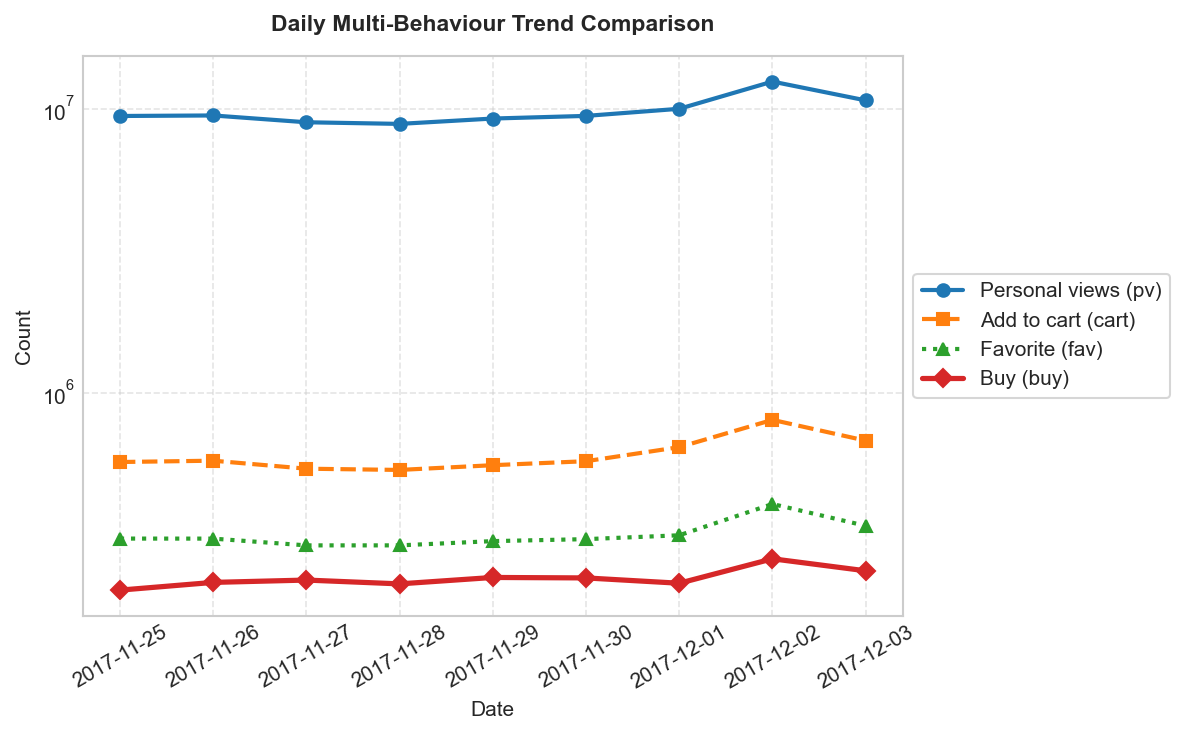

In [2]:
# import modules for plotting
import pandas as pd
import matplotlib.pyplot as plt

# read EDA data
summary = pd.read_csv('output/total_behaviour_summary.csv')
# filter calibration and holdout period
filter_date_summary = summary[summary['date'] >= '2017-11-25']

# find the date row and behaviour_type columns
final_summary = filter_date_summary.pivot(index='date', columns='behaviour_type', values='count').fillna(0) #use fillna to replace null into 0

#parameter of part of dec
plt.figure(figsize=(8,5), dpi=150)
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
colors = {'pv': '#1f77b4', 'cart': '#ff7f0e', 'fav': '#2ca02c', 'buy': '#d62728'}
styles = {
    'pv': {'linestyle': '-', 'marker': 'o', 'linewidth': 2, 'label': 'Personal views (pv)'},
    'cart': {'linestyle': '--', 'marker': 's', 'linewidth': 2, 'label': 'Add to cart (cart)'},
    'fav': {'linestyle': ':', 'marker': '^', 'linewidth': 2, 'label': 'Favorite (fav)'},
    'buy': {'linestyle': '-', 'marker': 'D', 'linewidth': 2.5, 'label': 'Buy (buy)'}
} #set the shape of lines

#plot every single line
for i in ['pv', 'cart', 'fav', 'buy']:
    if i in final_summary.columns:
        plt.plot(
            final_summary.index,
            final_summary[i],
            color=colors[i],
            **styles[i] # unpack style that set before
        )
# dec
plt.title('Daily Multi-Behaviour Trend Comparison', fontsize=11, fontweight='bold', pad=12)
plt.xlabel('Date', fontsize=10)
plt.ylabel('Count', fontsize=10)
plt.yscale('log') # use log aixes to aviod personal views overcounts
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(rotation=30) #rotae labels aviod overlapping
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=True)
plt.tight_layout()

# save
plt.savefig('figures/EDA/fig1_behavior_trend.png', dpi=300, bbox_inches='tight')
plt.show()

3. Visulization for Behavior Conversion Funnel Chart

After EDA, we could get  every user's counts of behaviour type. In order to present the objective user's behaviour type, we could use these user bahaviour deature above to visualize Behavior Conversion Funnel Chart plot of users

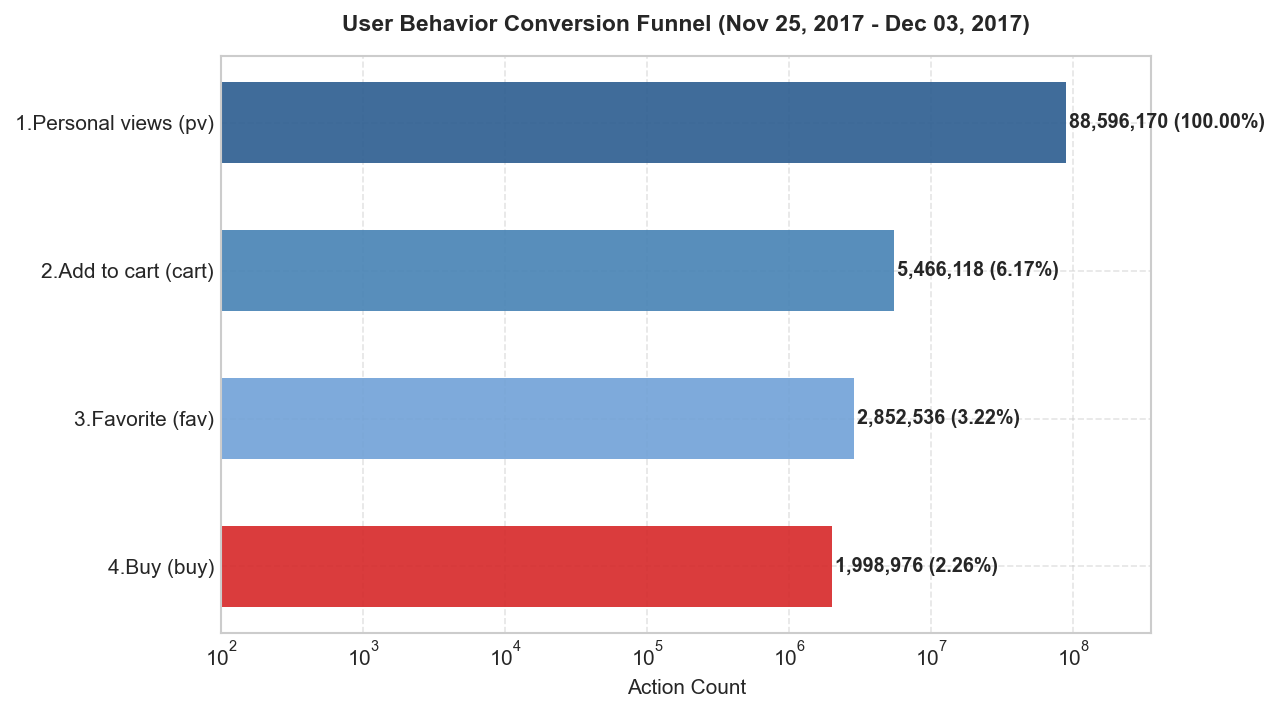

In [3]:
# read user features data
feature_summary = pd.read_csv('output/total_behaviour_summary.csv')

# filter outlier date
feature_summary = feature_summary[feature_summary['date'] >= '2017-11-25']

# behaviour clustering
total_behaviour = feature_summary.groupby('behaviour_type')['count'].sum()
stages = ['1.Personal views (pv)', '2.Add to cart (cart)', '3.Favorite (fav)', '4.Buy (buy)'] # set y-axis labels
counts = [
    total_behaviour['pv'],
    total_behaviour['cart'],
    total_behaviour['fav'],
    total_behaviour['buy']
]

# calculate total transfer ratio (compared with initial)
pv_base = counts[0]
trans_pct = []
for c in counts:
    pct = (c / pv_base) *100
    trans_pct.append(pct)

# plotting funnel chart
plt.figure(figsize=(8,5), dpi=150)
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
colors = ['#2b5c8f', '#4682b4', '#70a1d7', '#d62728']

# reverse-order rendering (let PV at the top)
bars = plt.barh(stages[::-1], counts[::-1], color=colors[::-1], height=0.55, alpha=0.9)

# notice the behaviour numbers and convertion ratio on the right
for bar, count, pct in zip(bars, counts[::-1], trans_pct[::-1]):
    width = bar.get_width()
    plt.text(
        width * 1.05, 
        bar.get_y() + bar.get_height()/2, 
        f"{count:,} ({pct:.2f}%)", 
        va='center', 
        ha='left', 
        fontsize=9.5, 
        fontweight='bold'
    )

# dec
plt.title('User Behavior Conversion Funnel (Nov 25, 2017 - Dec 03, 2017)', fontsize=11, fontweight='bold', pad=12)
plt.xlabel('Action Count', fontsize=10)
plt.xscale('log')
plt.xlim(100, max(counts) * 4) # set extra space for notes
plt.grid(True, linestyle='--', alpha=0.5, axis='both')
plt.tight_layout

#save
plt.savefig('figures/EDA/fig2_behavior_conversion_funnel.png', dpi=300, bbox_inches='tight')
plt.show()

4. Visulization for 24-Hour Micro-Interaction Pattern of users

To further refine the analysis of the temporal characteristics of user purchasing behaviours, we break down user purchasing behavior across the 24-hour day to conduct quantitative analysis in different time periods.

In [4]:
# pre-set
data_path = r'../data/UserBehavior.csv'
column_names = ['user_id', 'item_id', 'category_id', 'behaviour_type', 'timestamp']
chunk_size = 1000000
start_ts = 1511539200
end_ts = 1512316800
hour_behaviour_list=[]

# filter date
for chunk in pd.read_csv(data_path, header=None, names=column_names, chunksize=chunk_size):
    valid_chunk = chunk[(chunk['timestamp'] >= start_ts) & (chunk['timestamp'] <= end_ts)].copy()
    if not valid_chunk.empty:
        # convert into BeiJing time date(AliBaBa base in China) + 28800s
        valid_chunk['hour'] = pd.to_datetime(valid_chunk['timestamp'] + 28800, unit='s').dt.hour
        # cluster the hour and behaviour_type
        hourly_stats = valid_chunk.groupby(['hour', 'behaviour_type']).size().reset_index(name='count')
        hour_behaviour_list.append(hourly_stats)

# save as a independent csv file
hour_behaviour_summary = pd.concat(hour_behaviour_list, axis=0).groupby(['hour', 'behaviour_type'])['count'].sum().reset_index()
hour_behaviour_summary.to_csv('output/fig3_hour_behaviour_summary.csv', index=False)

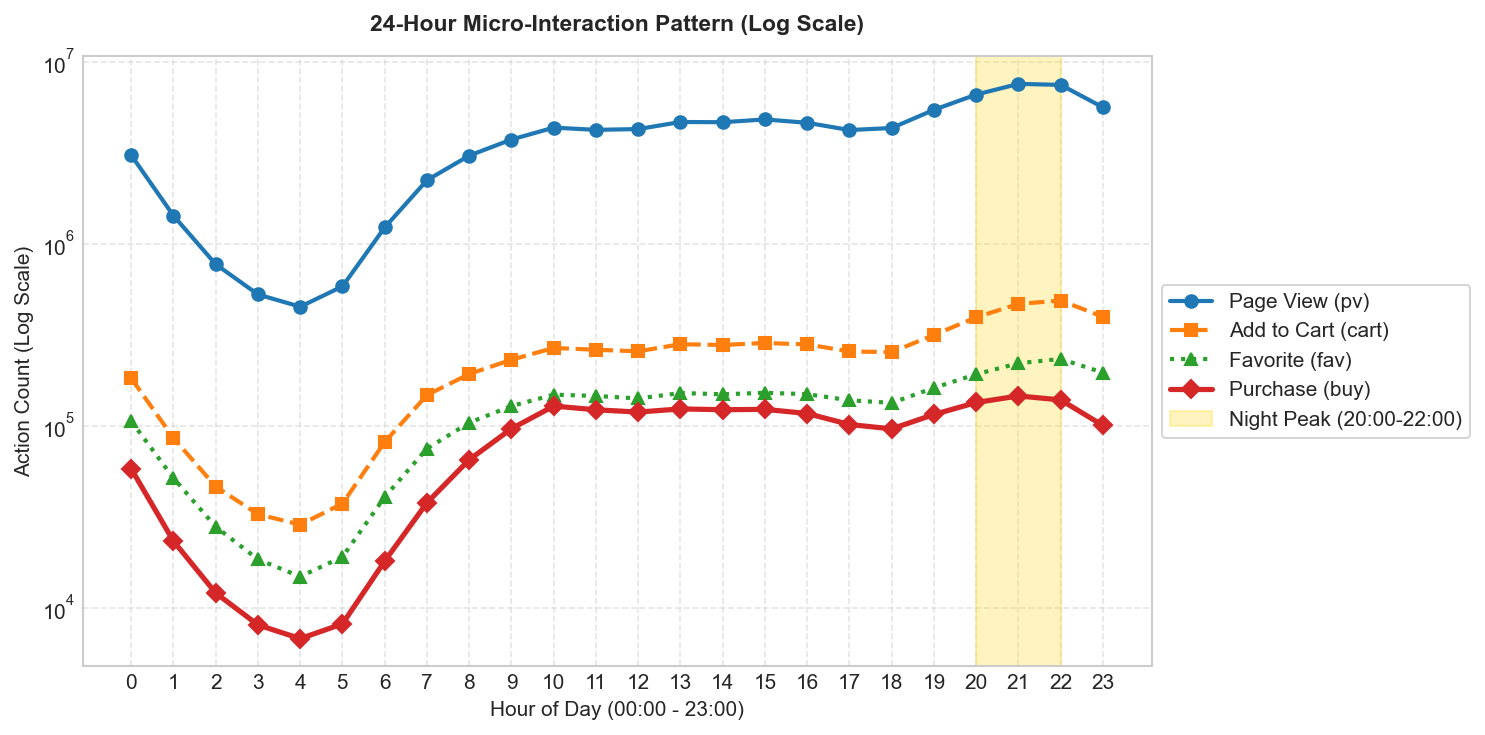

In [5]:
# read pre-process independent csv file
hour_summary = pd.read_csv('output/fig3_hour_behaviour_summary.csv')

# take hour as index and behaviour_type as column
pivot_hour_summary = hour_summary.pivot(index='hour', columns='behaviour_type', values='count').fillna(0)

# set plotting parameters
plt.figure(figsize=(10, 5), dpi=150)
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

colors = {'pv': '#1f77b4', 'cart': '#ff7f0e', 'fav': '#2ca02c', 'buy': '#d62728'}
styles = {
    'pv': {'linestyle': '-', 'marker': 'o', 'linewidth': 2, 'label': 'Page View (pv)'},
    'cart': {'linestyle': '--', 'marker': 's', 'linewidth': 2, 'label': 'Add to Cart (cart)'},
    'fav': {'linestyle': ':', 'marker': '^', 'linewidth': 2, 'label': 'Favorite (fav)'},
    'buy': {'linestyle': '-', 'marker': 'D', 'linewidth': 2.5, 'label': 'Purchase (buy)'}
}

# plot every 4 behaviours in 24h
for behavior in ['pv', 'cart', 'fav', 'buy']:
    if behavior in pivot_hour_summary.columns:
        plt.plot(
            pivot_hour_summary.index, 
            pivot_hour_summary[behavior], 
            color=colors[behavior],
            **styles[behavior]
        )

# highlight golden time, where behaviour represent the most
plt.axvspan(20, 22, color='gold', alpha=0.25, label='Night Peak (20:00-22:00)')

# dec
plt.title("24-Hour Micro-Interaction Pattern (Log Scale)", fontsize=11, fontweight='bold', pad=12)
plt.xlabel("Hour of Day (00:00 - 23:00)", fontsize=10)
plt.ylabel("Action Count (Log Scale)", fontsize=10)
plt.yscale('log')
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=True)
plt.tight_layout()

# save
plt.savefig('figures/EDA/fig3_hour_behaviour_summary.png', dpi=300, bbox_inches='tight')
plt.show()

5. Visualization for Calibration Period Purchase Frequency Long-Tail Distribution

5.1 Providing the mathematical rationale for the first stage—the BG/NBD probabilistic model:
Traditional stochastic models (such as OLS linear regression) require data to follow a normal distribution. Calibration Period Purchase Frequency Long-Tail Distribution could visually demonstrates that e-commerce repeat-purchase data exhibits extreme right-skewness and zero-inflation, characterized by a long tail. This serves as a key justification for employing the BG/NBD model.

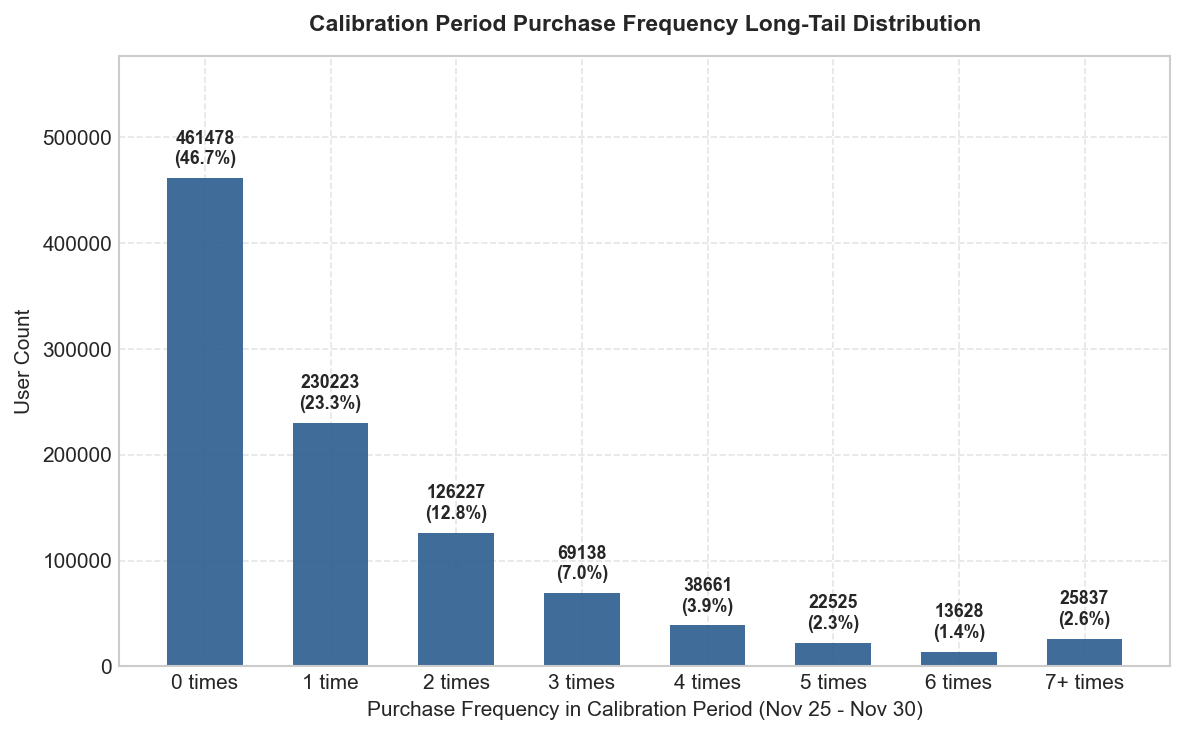

In [6]:
# read pre-cleaned feature data
micro_user_feature = pd.read_csv('output/user_micro_behavior_features.csv')

# filter user buying counts from calibration date
cali_user_buy_counts = micro_user_feature['buy_count_cal'].value_counts().sort_index()

# combine the counts above 7 times into 7 times +
freq_series = cali_user_buy_counts.copy()
freq_7_plus = freq_series[freq_series.index >= 7].sum()

plot_data = freq_series[freq_series.index < 7].tolist() + [freq_7_plus]
x_labels = ['0 times', '1 time', '2 times', '3 times', '4 times', '5 times', '6 times', '7+ times']

# set plotting
plt.figure(figsize=(8, 5), dpi=150)
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

# draw bar chart
total_users = len(micro_user_feature)
bars = plt.bar(range(len(plot_data)), plot_data, color='#2b5c8f', width=0.6, alpha=0.9)

# notes the percentage of user buy in different frequency
for bar, val in zip(bars, plot_data):
    pct = (val / total_users) * 100
    plt.text(
        bar.get_x() + bar.get_width() / 2, 
        val + (max(plot_data) * 0.02), 
        f"{val}\n({pct:.1f}%)", 
        ha='center', 
        va='bottom', 
        fontsize=8.5,
        fontweight='bold'
    )

# dec
plt.title("Calibration Period Purchase Frequency Long-Tail Distribution", fontsize=11, fontweight='bold', pad=12)
plt.xlabel("Purchase Frequency in Calibration Period (Nov 25 - Nov 30)", fontsize=10)
plt.ylabel("User Count", fontsize=10)
plt.xticks(range(len(x_labels)), x_labels)
plt.ylim(0, max(plot_data) * 1.25)  # space for notes
plt.grid(True, linestyle='--', alpha=0.5, axis='both')
plt.tight_layout()

# save
save_path = 'frequency_long_tail_distribution.png'
plt.savefig('figures/EDA/fig4_frequency_long_tail_distribution.png', dpi=300, bbox_inches='tight')
plt.show()